c:\Users\Nils\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


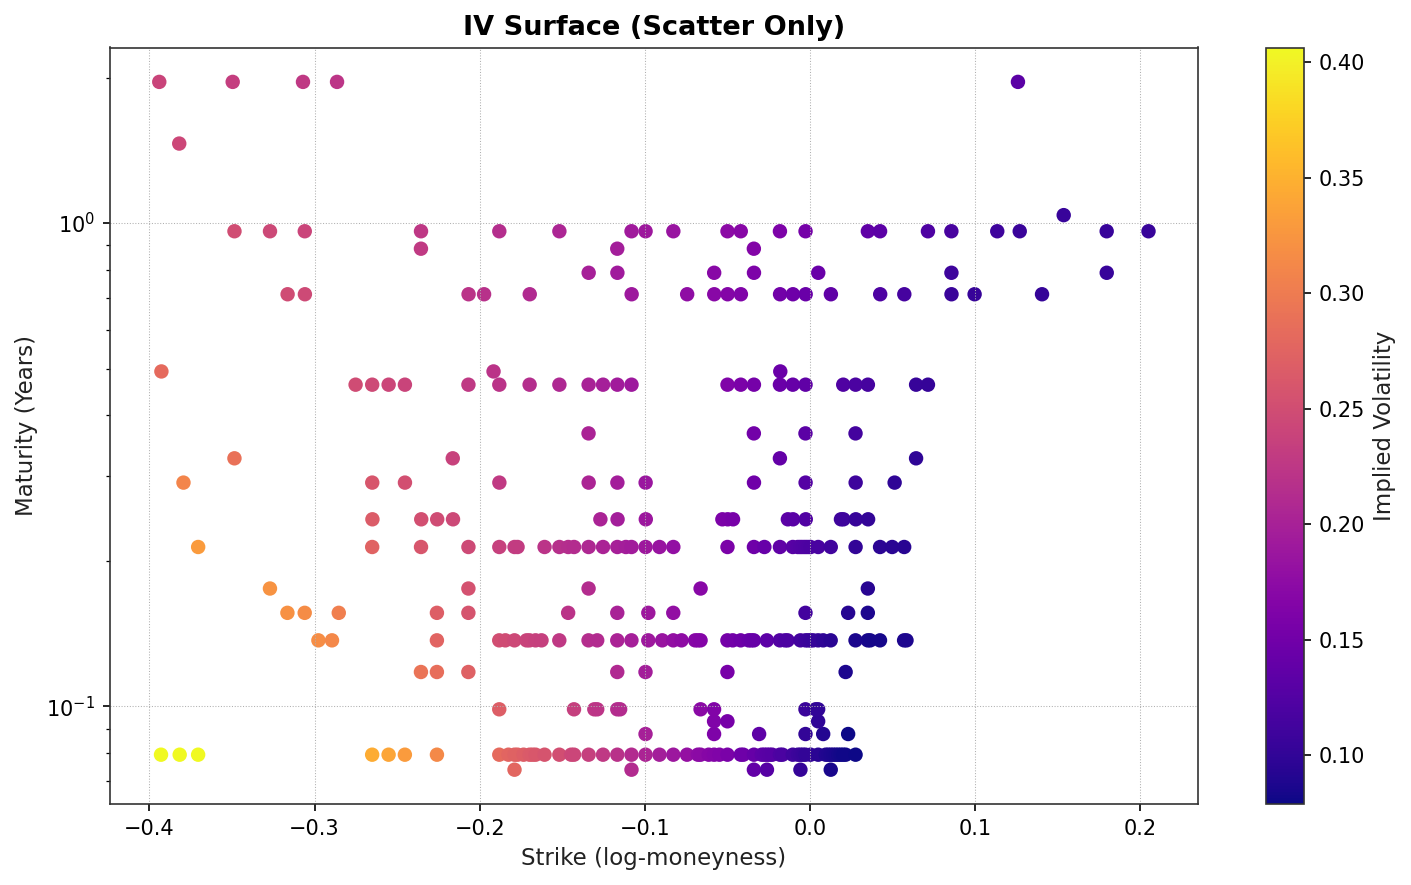

In [19]:
import pandas as pd
import numpy as np
import sys, os
from typing import List, Tuple
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from generation.utils import plot_iv_surface_scatter, preprocess_and_filter_otm, build_market_surfaces
from models.framework import DeepONet, MLP

df = pd.read_csv("C:/Users/Nils/nn_stochvol_calibrations/real_calibration/data_download.csv")
df = preprocess_and_filter_otm(df)
surfaces = build_market_surfaces(df)
plot_iv_surface_scatter(surfaces[0]["iv_surface"],surfaces[0]["grid"]["strikes"],np.exp(surfaces[0]["grid"]["maturities"]))

In [16]:
model_path="C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/deeponet.pth"
x = DeepONet.load(model_path)
deeponet_res = []
for surface in surfaces:
    res = x.calibrate(surface, optimiser="lm", maxiter=500)
    res["date"] = surface["date"]
    deeponet_res.append(res)

✅ Loaded DeepONet from C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/deeponet.pth


In [22]:
model_path="C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/mlp.pth"
y = MLP.load(model_path)
mlp_res = []
for surface in surfaces:
    res = y.calibrate(surface, optimiser="lm", maxiter=500)
    res["date"] = surface["date"]
    mlp_res.append(res)

✅ Loaded MLP from C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/mlp.pth


In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

# Proper names for your params
PARAM_NAMES = ["eta", "rho", "H"] + [f"xi0_{i}" for i in range(5)]


def prepare_df(res_list, name):
    df = pd.DataFrame([{
        "date": r["date"],
        "rmse": r["rmse"],
        "runtime_ms": r["runtime_ms"],
        **{PARAM_NAMES[i]: r["theta_hat"][i] for i in range(len(r["theta_hat"]))}
    } for r in res_list])

    df["model"] = name
    df["date"] = pd.to_datetime(df["date"])
    return df


def plot_param_grid(deeponet_res, mlp_res):

    # Build dfs
    df_deep = prepare_df(deeponet_res, "DeepONet")
    df_mlp  = prepare_df(mlp_res, "MLP")

    df = pd.concat([df_deep, df_mlp], ignore_index=True)
    # IMPORTANT: sort chronologically
    df = df.sort_values("date")

    for i in range(2):
        idx_max = df["rmse"].idxmax()
        row_max = df.loc[idx_max]

        print("\n⚠️ Maximum RMSE entry removed:")
        print(row_max[["date", "model", "rmse"]])

        df = df.drop(idx_max).reset_index(drop=True)
# ------------------------------

    param_cols = PARAM_NAMES
    n_params = len(param_cols)

    # Grid size (parameters + 2 rows: RMSE + runtime)
    rows = math.ceil(n_params / 2) + 1
    cols = 2

    fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 3))
    axes = axes.flatten()

    # ---- Parameter Plots ----
    for idx, p in enumerate(param_cols):
        ax = axes[idx]
        for model, sub in df.groupby("model"):
            ax.plot(sub["date"], sub[p], marker="o", label=model)
        ax.set_title(p)
        ax.set_xlabel("Date")
        ax.set_ylabel("Value")
        ax.grid(True)

        # Legend nur in erstem Parameter-Plot
        if idx == 0:
            ax.legend()

    # ---- RMSE ----
    rmse_ax = axes[n_params]
    for model, sub in df.groupby("model"):
        rmse_ax.plot(sub["date"], sub["rmse"], marker="o", label=model)
    rmse_ax.set_title("RMSE over Time")
    rmse_ax.set_xlabel("Date")
    rmse_ax.set_ylabel("RMSE")
    rmse_ax.grid(True)
    #rmse_ax.legend()

    # ---- Runtime ----
    runtime_ax = axes[n_params + 1]
    for model, sub in df.groupby("model"):
        runtime_ax.plot(sub["date"], sub["runtime_ms"], marker="o", label=model)
    runtime_ax.set_title("Calibration Runtime (ms)")
    runtime_ax.set_xlabel("Date")
    runtime_ax.set_ylabel("Runtime [ms]")
    runtime_ax.grid(True)
    #runtime_ax.legend()

    plt.tight_layout()
    plt.show()

    # ---- Print average runtimes ----
    print("\nAverage Calibration Runtime (ms):")
    print(df.groupby("model")["runtime_ms"].mean())

    # ---- Print average RMSE ----
    print("\nAverage RMSE:")
    print(df.groupby("model")["rmse"].mean())




⚠️ Maximum RMSE entry removed:
date     2020-04-01 00:00:00
model                    MLP
rmse                0.087378
Name: 63, dtype: object

⚠️ Maximum RMSE entry removed:
date     2020-04-01 00:00:00
model               DeepONet
rmse                0.086905
Name: 6, dtype: object


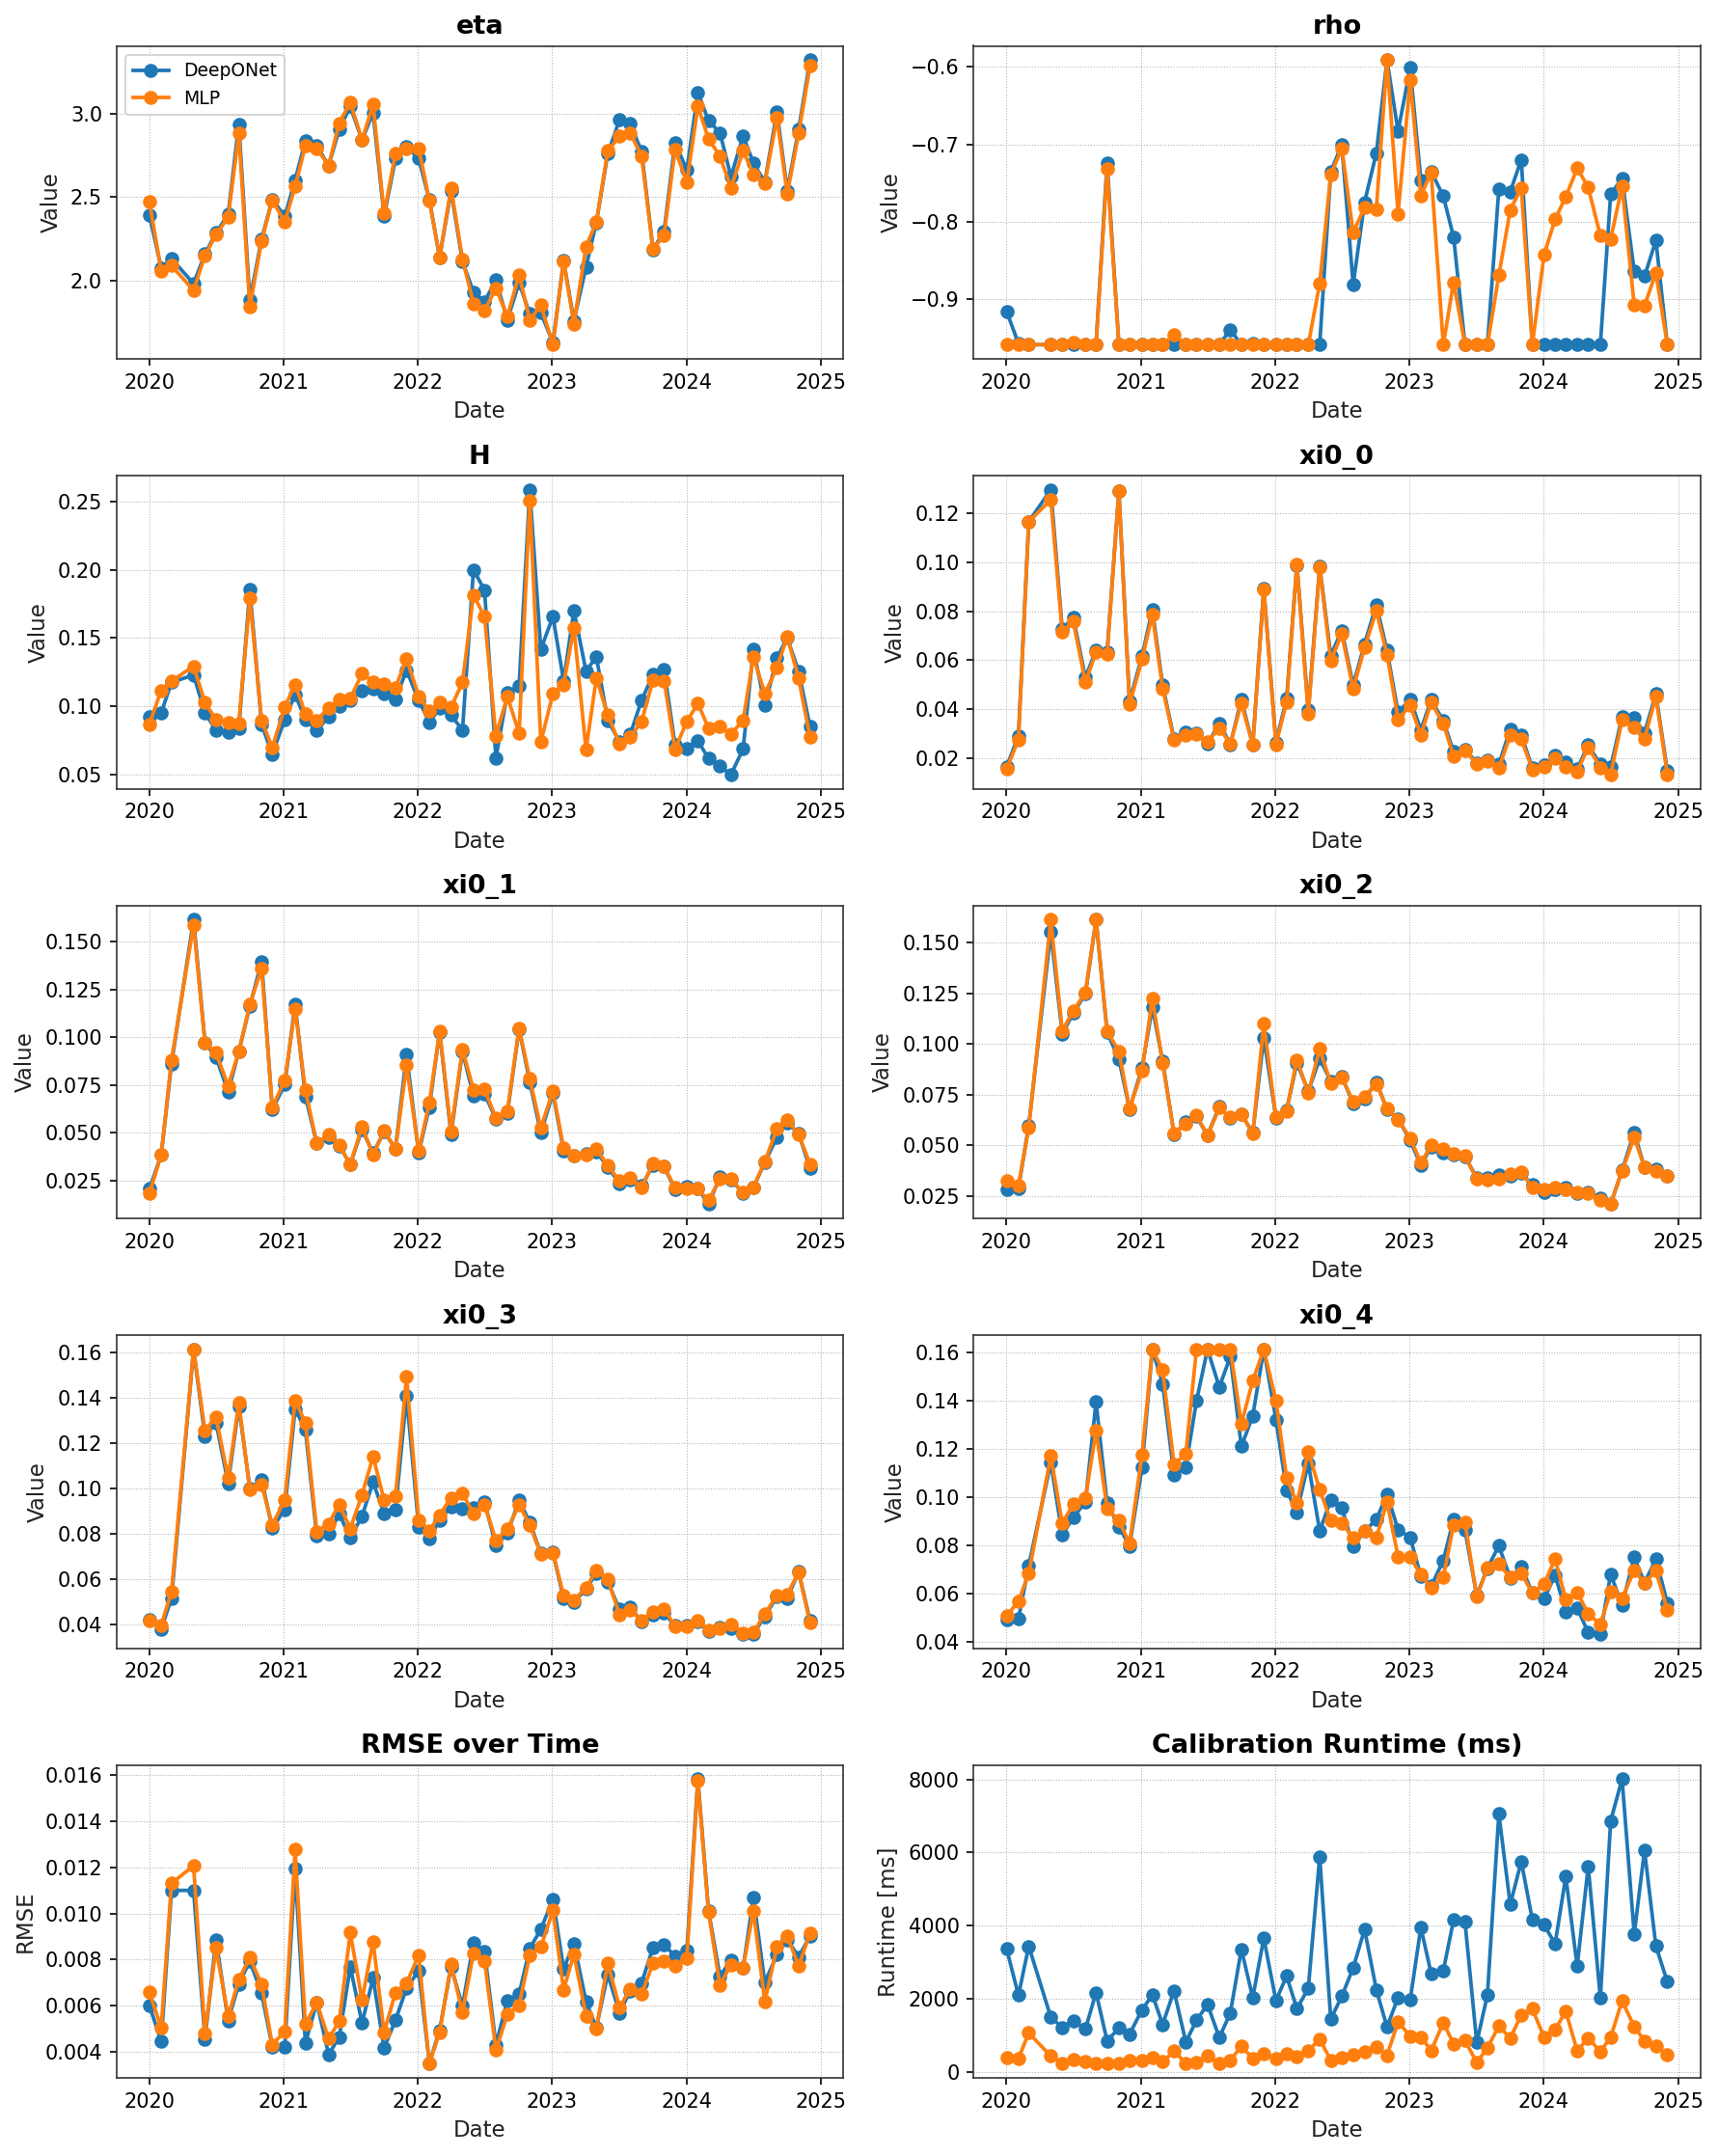


Average Calibration Runtime (ms):
model
DeepONet    2891.554490
MLP          666.976598
Name: runtime_ms, dtype: float64

Average RMSE:
model
DeepONet    0.007279
MLP         0.007349
Name: rmse, dtype: float64


In [57]:
plot_param_grid(deeponet_res, mlp_res)


## Validation of some results

In [58]:
len(deeponet_res)

60

RMSE:  0.009961312


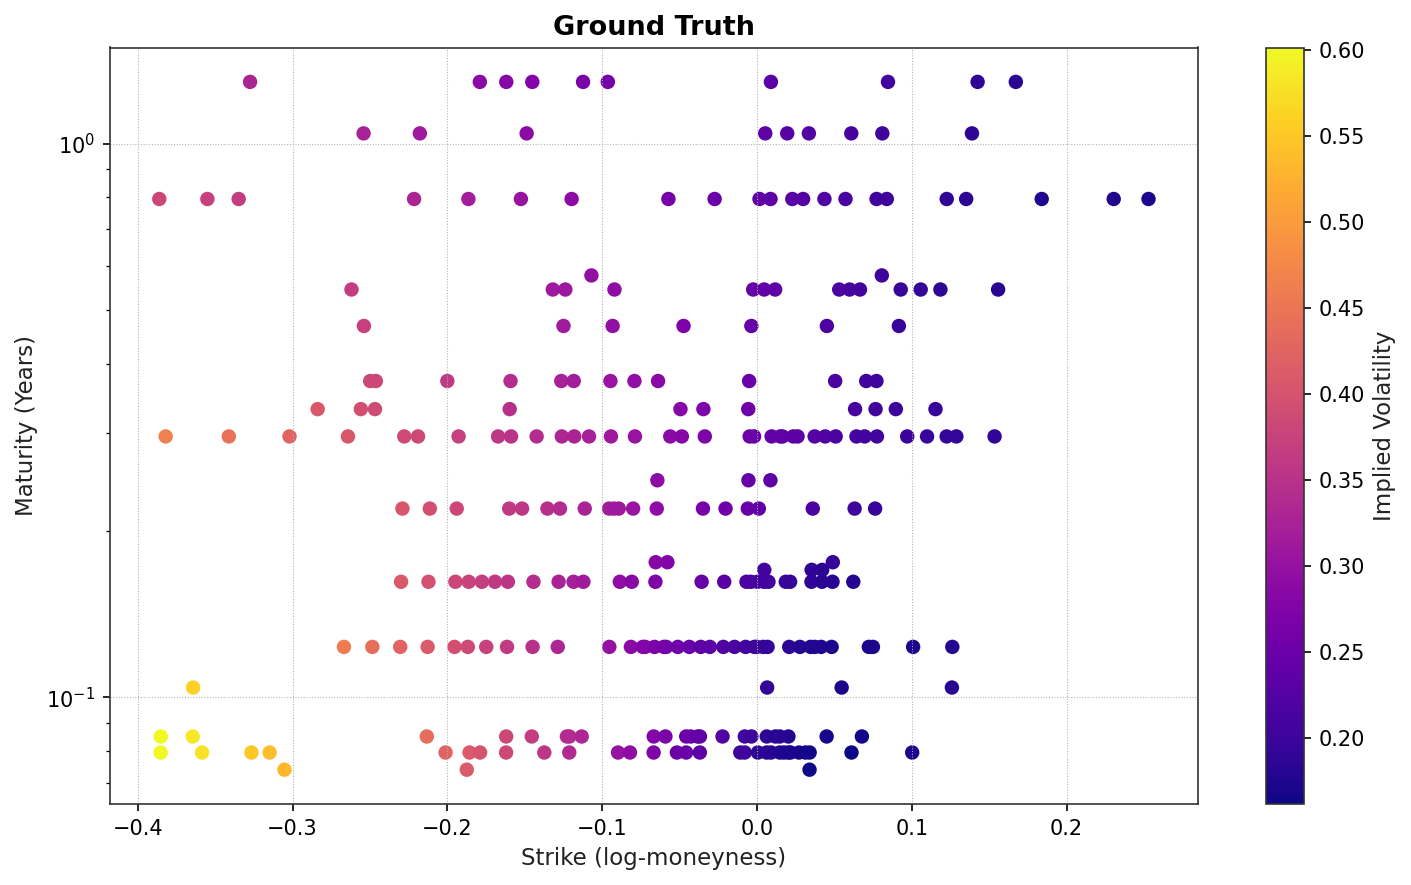

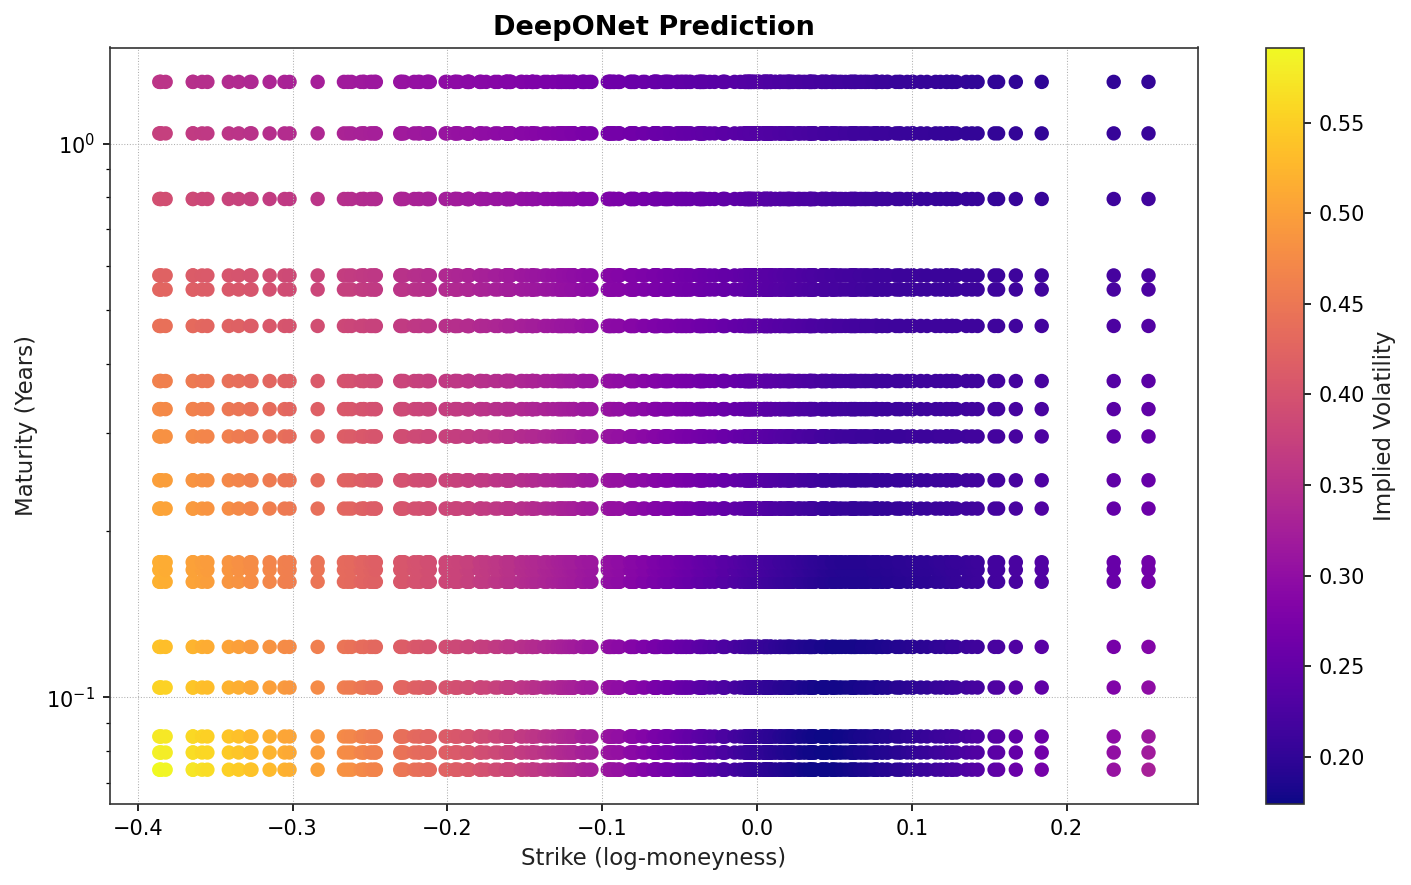

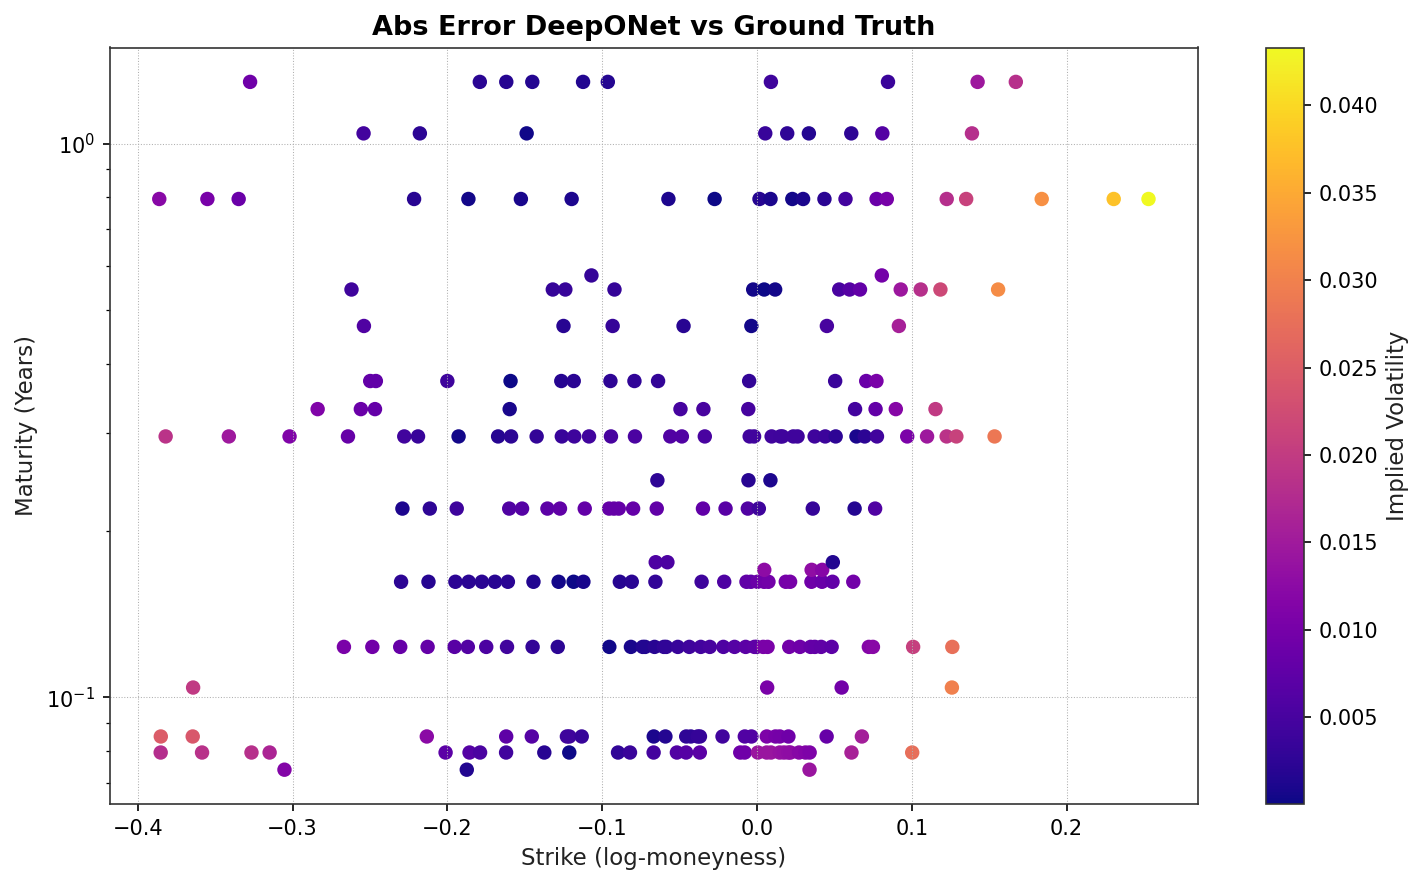

In [66]:
j = 8

p = deeponet_res[j]["theta_hat"]
params = {'eta':  p[0],
 'rho': p[1]+0.1,
 'H': p[2],
 'xi0_knots': p[3:]}

k = x.predict_surface(params, grid=surfaces[j]["grid"]).detach().numpy()
print("RMSE: ",np.sqrt(np.nanmean((k-surfaces[j]["iv_surface"])**2)))
plot_iv_surface_scatter(surfaces[j]["iv_surface"],surfaces[j]["grid"]["strikes"],np.exp(surfaces[j]["grid"]["maturities"]), title="Ground Truth")
plot_iv_surface_scatter(k,surfaces[j]["grid"]["strikes"],np.exp(surfaces[j]["grid"]["maturities"]), title="DeepONet Prediction")
plot_iv_surface_scatter(np.abs(k-surfaces[j]["iv_surface"]),surfaces[j]["grid"]["strikes"],np.exp(surfaces[j]["grid"]["maturities"]), title="Abs Error DeepONet vs Ground Truth")